# Step - 1: Install the packages

In [ ]:
# Install required packages
!pip install langchain langchain-community pillow pymupdf python-dotenv  # Packages
'''
langchain             : RAG Framework like Memory ; Chain ; Tools ; Agents
langchain-community   : To connect with external sources like pdf ; dox ; images
pillow                : To work with images like Load & display the images
pymupdf               : To work with pdf files
python-dotenv         : To load the environment variables like hiding keys
'''

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


'\nlangchain             : RAG Framework like Memory ; Chain ; Tools ; Agents\nlangchain-community   : To connect with external sources like pdf ; dox ; images\npillow                : To work with images like Load & display the images\npymupdf               : To work with pdf files\npython-dotenv         : To load the environment variables like hiding keys\n'

In [ ]:
!pip install langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
pip install -U langchain-cohere


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.4/295.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 64.6 MB/s eta 0:00:00
  Attempting uninstall: httpx-sse
    Found existing installation: httpx-sse 0.4.1
    Uninstalling httpx-sse-0.4.1:
      Successfully uninstalled httpx-sse-0.4.1
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.75
    Uninstalling langchain-core-0.3.75:
      Successfully uninstalled langchain-core-0.3.75


# Step - 2: Import packages

In [ ]:
pip install langchain-cohere

In [ ]:
import fitz  # PyMuPDF
from PIL import Image
import io
import os
from dotenv import load_dotenv

import google.generativeai as genai

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_cohere import ChatCohere, CohereEmbeddings

load_dotenv()

False

# Step-3: Read the attention_is_all_you_need.pdf

In [ ]:
!wget https://arxiv.org/pdf/1706.03762 # https://arxiv.org/pdf/1706.03762 : Is a research paper file link
!mv 1706.03762 attention_is_all_you_need.pdf

'''
attention_is_all_you_need.pdf : Is used to demonstrate the RAG framework & also helps in downloading PDF files from ONLINE
'''

--2025-09-14 09:59:59--  https://arxiv.org/pdf/1706.03762
Resolving arxiv.org (arxiv.org)... 151.101.3.42, 151.101.131.42, 151.101.67.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.3.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2215244 (2.1M) [application/pdf]
Saving to: ‘1706.03762’

1706.03762          100%[===================>]   2.11M  --.-KB/s    in 0.07s   

2025-09-14 09:59:59 (28.3 MB/s) - ‘1706.03762’ saved [2215244/2215244]



'\nattention_is_all_you_need.pdf : Is used to demonstrate the RAG framework & also helps in downloading PDF files from ONLINE\n'

In [ ]:
pdf_file=fitz.open('attention_is_all_you_need.pdf') # In order to know how many pages are there in the pdf we need to open the pdf file

In [ ]:
len(pdf_file) # Length : 15 pages

15

In [ ]:
page = pdf_file[1]
page

page 1 of attention_is_all_you_need.pdf

In [ ]:
 text = page.get_text().strip()
 print(text)
 # Present in the pdf

1
Introduction
Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks
in particular, have been firmly established as state of the art approaches in sequence modeling and
transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous
efforts have since continued to push the boundaries of recurrent language models and encoder-decoder
architectures [38, 24, 15].
Recurrent models typically factor computation along the symbol positions of the input and output
sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden
states ht, as a function of the previous hidden state ht−1 and the input for position t. This inherently
sequential nature precludes parallelization within training examples, which becomes critical at longer
sequence lengths, as memory constraints limit batching across examples. Recent work has achieved
significant improvements in computational efficiency through factor

<h1><b>Image Page</b></h1>

In [ ]:
page = pdf_file[2]  # Image is available in 3rd page of pdf but in python it's index = 2
text = page.get_text().strip()
print(text)
# But we're not printing image we're ONLY extracting the TEXT from page 3

Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1,
respectively.
3.1
Encoder and Decoder Stacks
Encoder:
The encoder is composed of a stack of N = 6 identical layers. Each layer has two
sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-
wise fully connected feed-forward network. We employ a residual connection [11] around each of
the two sub-layers, followed by layer normalization [1]. That is, the output of each sub-layer is
LayerNorm(x + Sublayer(x)), where Sublayer(x) is the function implemented by the sub-layer
itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding
layers, produce outputs of dimension dmodel = 512.
Decoder:
The decoder is also composed of a stack of N = 6 identical layers. 

In [ ]:
images = page.get_images(full=True)
images # The output indicates only 1 image is available in that page

[(128, 175, 1520, 2239, 8, 'DeviceRGB', '', 'Im1', 'FlateDecode', 0)]

In [ ]:
len(images) # Means in this page only 1 image is available*

1

In [ ]:
images[0] # 1 image

# xref : It is a reference number in PDF or a unique id of the image

(128, 175, 1520, 2239, 8, 'DeviceRGB', '', 'Im1', 'FlateDecode', 0)

In [ ]:
images[0][0] # LIST INDEXING 1 image = 0 ; Extract the 1st number "128" in image so index = 0

128

In [ ]:
images[0][1]

175

In [ ]:
images[0][3]

2239

In [ ]:
images[0][2]

1520

In [ ]:
xref=images[0][0]
xref # This is called the hyperlink of the image

# xref : It is a reference number in PDF or a unique id of the image

128

In [ ]:
# extract the image
base_image = pdf_file.extract_image(xref)
image_bytes = base_image["image"] # image is encoded in bytes data
#image_bytes

In [ ]:
image_bytes # Image data is encoded in the form of bytes

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x05\xf0\x00\x00\x08\xbf\x08\x02\x00\x00\x00\r\x81$Y\x00\x00\x00\tpHYs\x00\x00\x0e\xc4\x00\x00\x0e\xc4\x01\x95+\x0e\x1b\x00\x01\xd9NIDATx\x9c\xec\xdd\xff\xcf\x1dW\x9d\'\xf8\xe7?q\x9c\x1f\x9c\xbf\xc3\x86\xd0^i\xb4Rc\xdc\x19\xb4\xdb\xb4CH\xcf\xa0\xb1\xf1d\xa1\xe9\x98\x0c\x88V<\xeb!\x03V\x06\x0b\x1a"C\x00\x11\x02\x81\xde\x9d\xd8"b\x93\xe6Kw -\xb0;\xc9\x8eX\x88\x93\x1e\x8d\xc4\xc8O#\xcd\x0f+\xc5#\xed\x8f\xbd\x85\xaf\xa89\xa9{\xef\xb9\xa7\xaan\xd5\xa9:\xf5z\xe9\xa3Vx\\\xf7\xd4\xa9\xbaU\xe7y\xce\xbb\xeb\xcb\xc1?\x01\x00\x00\x000+\x07\xb9;\x00\x00\x00\x00@;\x02\x1d\x00\x00\x00\x80\x99\x11\xe8\x00\x00\x00\x00\xcc\x8c@\x07\x00\x00\x00`f\x04:\x00\x00\x00\x003#\xd0\x01\x00\x00\x00\x98\x19\x81\x0e\x00\x00\x00\xc0\xcc\x08t\x00\x00`\xb3\x834\xb9\xbb\t\xc0\x12\xf9\xf5\x03\x00\x00M\x89Q\x8ed\x07\x80\\\xfc\xd6\x01\x00\x80\xff\xa1[\x94#\xd6\x01`d~\xdf\x00\x00\xc0\xef\xf4\x8fr&\x1e\xebL\xbc{\xe3\xb0\x13\x80b\x18\xc5\x00\x00`w\x9a\xb3\x97\x8f\xe45\xe5\xbe\x8d\x

<h1><b>Display the image</b></h1>

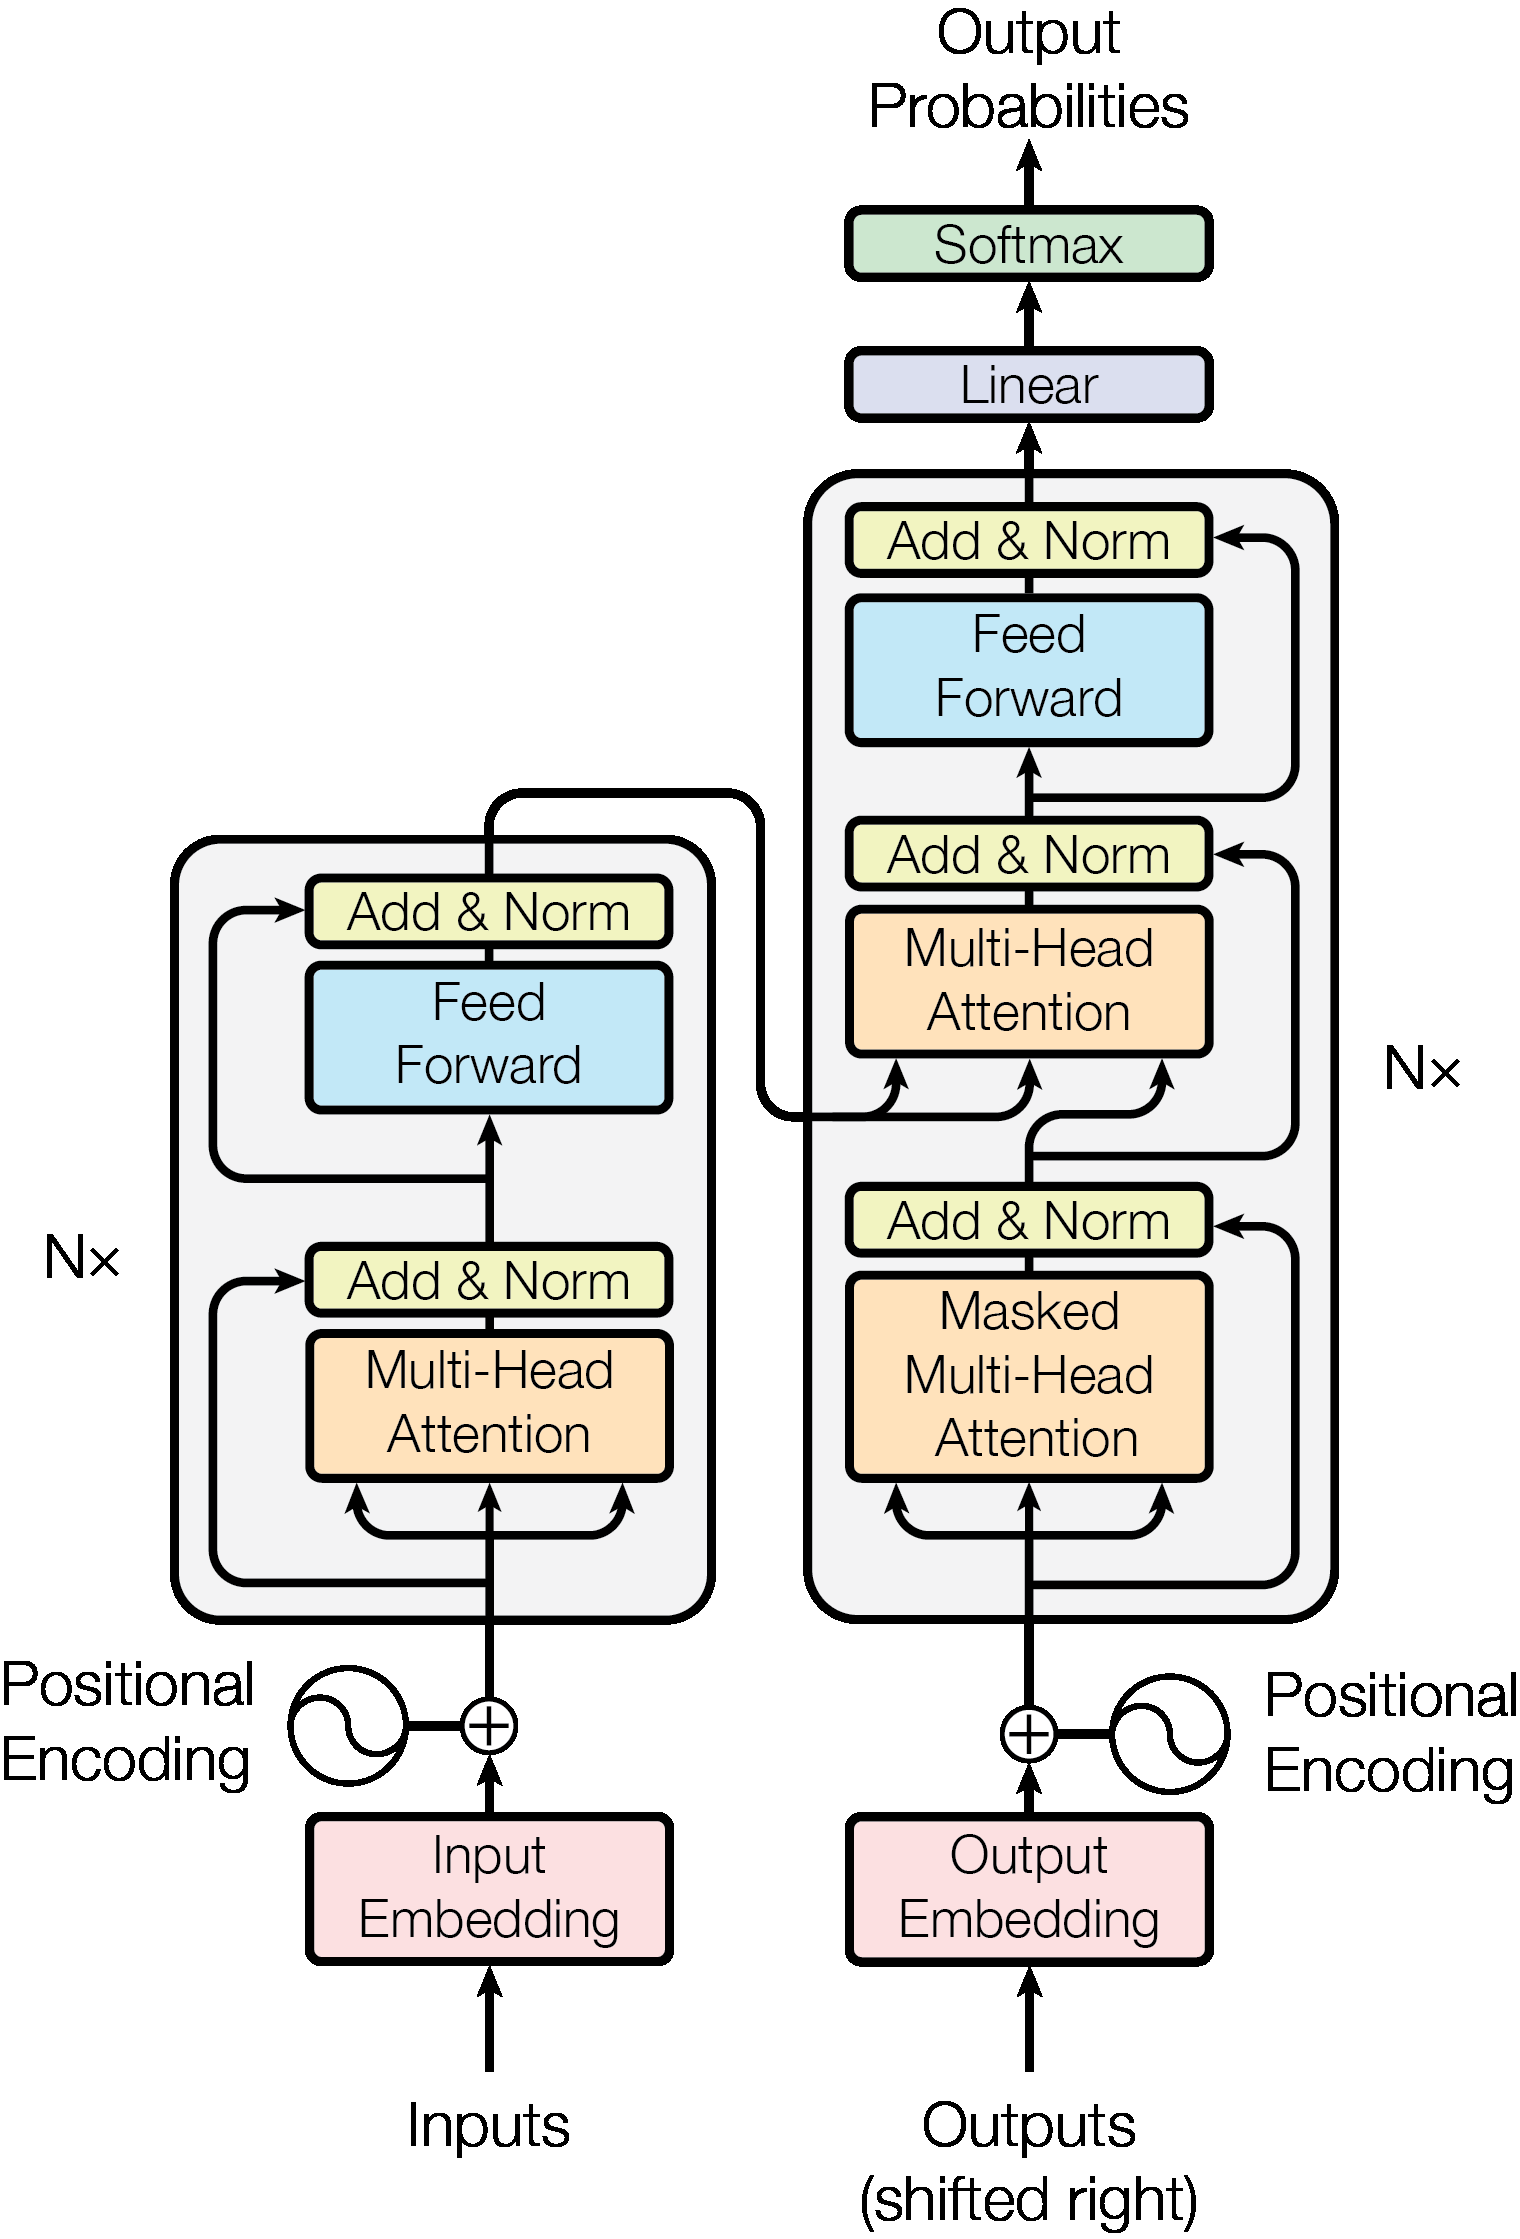

In [ ]:
from PIL import Image # PIL : Pillow Package
import io  # io Package

# convert bytes to a PIL image
image = Image.open(io.BytesIO(image_bytes))

# show the image (opens with default image viewer or inline in Jupyter)
image

# Extract the Text using Gemini

In [ ]:
from google.colab import userdata
api_key=userdata.get('gemini_Api')

In [ ]:
genai.configure(api_key=api_key)
model = genai.GenerativeModel(model_name="gemini-2.5-flash")

In [ ]:
response = model.generate_content([image, "You are an assistant tasked with summarizing tables, images and text for retrieval. \
    These summaries will be embedded and used to retrieve the raw text or table elements \
    Give a concise summary of the table or text that is well optimized for retrieval. Table or text or image:"])
response

response:
GenerateContentResponse(
    done=True,
    iterator=None,
    result=protos.GenerateContentResponse({
      "candidates": [
        {
          "content": {
            "parts": [
              {
                "text": "This image illustrates the Transformer neural network architecture, featuring an encoder-decoder structure. The encoder processes input sequences using multi-head self-attention, followed by a feed-forward network, with positional encodings added to input embeddings. The decoder generates output sequences, employing masked multi-head self-attention for previous outputs, a second multi-head attention layer that attends to the encoder's output, and a feed-forward network. Both encoder and decoder layers utilize residual connections and layer normalization (\"Add & Norm\"). The decoder's final output passes through a linear layer and a softmax layer to produce output probabilities. This architecture, prominent for sequence-to-sequence tasks like machine transla

In [ ]:
text=response.text
print(text)

This image illustrates the Transformer neural network architecture, featuring an encoder-decoder structure. The encoder processes input sequences using multi-head self-attention, followed by a feed-forward network, with positional encodings added to input embeddings. The decoder generates output sequences, employing masked multi-head self-attention for previous outputs, a second multi-head attention layer that attends to the encoder's output, and a feed-forward network. Both encoder and decoder layers utilize residual connections and layer normalization ("Add & Norm"). The decoder's final output passes through a linear layer and a softmax layer to produce output probabilities. This architecture, prominent for sequence-to-sequence tasks like machine translation, relies solely on attention mechanisms.


# All together : Automate Code
Means all the above 👆 individual cells in 1 single code cell

In [ ]:
text_data = []
img_data = []
with fitz.open('attention_is_all_you_need.pdf') as pdf_file:
    # Create a directory to store the images
    if not os.path.exists("extracted_images"):
        os.makedirs("extracted_images") # Saving the images in extracted_images folder

    # Loop through every page in the PDF
    for page_number in range(len(pdf_file)): # 15 papges in the pdf
        page = pdf_file[page_number]

        # Get the text on page
        text = page.get_text().strip() # Extarcted the text
        text_data.append({"response": text, "name": page_number+1}) # We appended the text data in a list
        # Get the list of images on the page
        images = page.get_images(full=True) # Append images in a list

        # Loop through all images found on the page
        for image_index, img in enumerate(images, start=0):
            xref = img[0]  # Get the XREF of the image
            base_image = pdf_file.extract_image(xref)  # Extract the image
            image_bytes = base_image["image"]  # Get the image bytes
            image_ext = base_image["ext"]  # Get the image extension

            # Load the image using PIL and save it
            image = Image.open(io.BytesIO(image_bytes))
            image.save(f"extracted_images/image_{page_number+1}_{image_index+1}.{image_ext}")
            # Saving the image file

In [ ]:
for img in os.listdir("extracted_images"):
    image = Image.open(f"extracted_images/{img}")
    response = model.generate_content([image, "You are an assistant tasked with summarizing tables, images and text for retrieval. \
    These summaries will be embedded and used to retrieve the raw text or table elements \
    Give a concise summary of the table or text that is well optimized for retrieval. Table or text or image:"])
    img_data.append({"response": response.text, "name": img})

In [ ]:
img_data

[{'response': 'The image illustrates the scaled dot-product attention mechanism. It takes Query (Q), Key (K), and Value (V) as inputs. Q and K are first multiplied (MatMul), then scaled, optionally masked, and a SoftMax function is applied. The resulting attention weights are then multiplied (MatMul) with V to produce the final output.',
  'name': 'image_4_1.png'},
 {'response': 'This image illustrates the architecture of a **Multi-Head Attention** mechanism, a key component in Transformer models. It shows how input Query (Q), Key (K), and Value (V) vectors are first transformed by multiple parallel **Linear** layers for each head. The outputs of these linear layers are then fed into `h` parallel **Scaled Dot-Product Attention** modules. The results from all `h` attention heads are then **Concatenated** and passed through a final **Linear** layer to produce the ultimate output of the multi-head attention block.',
  'name': 'image_4_2.png'},
 {'response': "The image illustrates the arch

In [ ]:
len(text_data)

15